# Cape Town's Short-Term Rental Market

**How much of "home sharing" in Cape Town is actually a commercial industry?**

Siyabonga Mfusi · Postgraduate Diploma in Data Analytics, IIE Varsity College

---

Airbnb's founding story is a spare room. The policy debate in Cape Town — a city with a serious
housing shortage — turns on whether that story still describes what is happening.

That is an empirical question, and the data can answer it. This notebook analyses **27,381 active
Cape Town listings** from an Inside Airbnb snapshot taken on 29 June 2026, plus **10 million rows**
of forward availability.

It asks four things:

1. **What is this market made of** — entire homes or spare rooms?
2. **Who owns it** — individual residents or multi-property operators?
3. **What drives price**, and which parts of the city command a premium?
4. **Is any of it licensed?**

The notebook also exports the aggregates that feed an interactive dashboard and a Power BI model,
so the same cleaned figures drive every downstream artefact.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
SEQ = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#2a78d6", "#1c5cab", "#104281"]
INK, INK_DIM, GRID, MUTED = "#0b0b0b", "#52514e", "#e4e3df", "#c9c8c3"

mpl.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": GRID, "axes.linewidth": 1.0,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "text.color": INK, "axes.labelcolor": INK_DIM, "xtick.color": INK_DIM, "ytick.color": INK_DIM,
    "font.size": 11, "axes.titlesize": 12.5, "axes.titleweight": "bold",
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
})

ROOT = Path("..") if (Path("..") / "src").exists() else Path(".")
DATA, OUTPUTS = ROOT / "data", ROOT / "outputs"
DASH, PBI = ROOT / "dashboard", ROOT / "powerbi"
for d in (OUTPUTS, DASH, PBI):
    d.mkdir(parents=True, exist_ok=True)

SNAPSHOT = "29 June 2026"
print("pandas", pd.__version__)

pandas 2.3.3


## 1. Load and clean

Two cleaning decisions matter more than the rest.

**Price is a formatted string** (`$1,231.00`) and has to be parsed. Despite the dollar sign, these
are **rand** — Inside Airbnb formats local currency with a `$`. A median of R1,735 a night for a
Cape Town entire home is plausible; $1,735 would not be.

**The top of the price distribution is not real.** The maximum reported nightly rate is close to
R1 million. Listings above R50,000 a night are placeholder or erroneous prices rather than a market
anyone transacts in, and they are excluded from price analysis — while still counting toward the
market's size and ownership structure.

In [2]:
lis = pd.read_csv(DATA / "listings.csv.gz", low_memory=False)
print(f"Raw listings: {len(lis):,}")

lis["price_zar"] = pd.to_numeric(
    lis.price.astype(str).str.replace(r"[$,]", "", regex=True), errors="coerce")

PRICE_CEILING = 50_000
steps = [("Listings in snapshot", len(lis))]

lis["has_price"] = lis.price_zar.notna()
steps.append(("With a published nightly price", int(lis.has_price.sum())))

lis["price_usable"] = lis.price_zar.where(
    lis.price_zar.between(50, PRICE_CEILING, inclusive="both"))
steps.append(("Price inside a credible range (R50-R50,000)", int(lis.price_usable.notna().sum())))

audit = pd.DataFrame(steps, columns=["Step", "Listings"])
audit["% of snapshot"] = (audit.Listings / len(lis) * 100).round(1)
print(audit.to_string(index=False))

print(f"\nExcluded as implausible: "
      f"{int(lis.has_price.sum() - lis.price_usable.notna().sum())} listings "
      f"(max reported R{lis.price_zar.max():,.0f}/night)")

Raw listings: 27,381
                                       Step  Listings  % of snapshot
                       Listings in snapshot     27381          100.0
             With a published nightly price     24542           89.6
Price inside a credible range (R50-R50,000)     24433           89.2

Excluded as implausible: 109 listings (max reported R999,537/night)


In [3]:
p = lis.price_usable.dropna()
print("Nightly price, rand:")
print(p.describe(percentiles=[.1, .25, .5, .75, .9, .99]).round(0).to_string())

Nightly price, rand:
count    24433.0
mean      3199.0
std       4486.0
min         57.0
10%        818.0
25%       1142.0
50%       1726.0
75%       3196.0
90%       6888.0
99%      23711.0
max      50000.0


## 2. What the market is made of

The first question is whether this is spare rooms or whole properties. It is not close.

In [4]:
mix = lis.room_type.value_counts().to_frame("listings")
mix["share"] = (mix.listings / len(lis) * 100).round(1)
mix["median_price"] = lis.groupby("room_type").price_usable.median().round(0)
print(mix.to_string())

entire = mix.loc["Entire home/apt", "share"]
print(f"\n{entire}% of Cape Town listings are entire homes or apartments — "
      f"whole properties removed from the residential rental pool, not spare rooms.")

                 listings  share  median_price
room_type                                     
Entire home/apt     23136   84.5        1884.0
Private room         4107   15.0        1020.0
Hotel room             83    0.3        1696.0
Shared room            55    0.2         502.0

84.5% of Cape Town listings are entire homes or apartments — whole properties removed from the residential rental pool, not spare rooms.


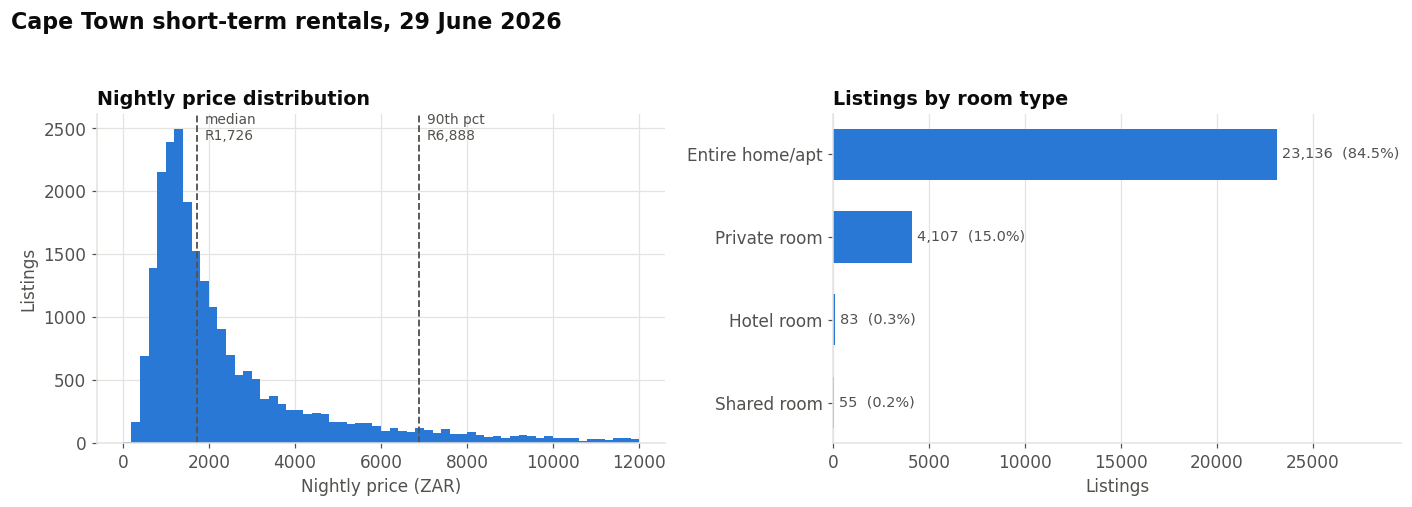

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

ax = axes[0]
ax.hist(p, bins=60, range=(0, 12000), color=SERIES[0])
for q, lab in [(p.median(), "median"), (p.quantile(0.9), "90th pct")]:
    ax.axvline(q, color=INK_DIM, linestyle="--", linewidth=1.2)
    ax.text(q + 180, ax.get_ylim()[1] * 0.92, f"{lab}\nR{q:,.0f}", fontsize=9, color=INK_DIM)
ax.set_xlabel("Nightly price (ZAR)")
ax.set_ylabel("Listings")
ax.set_title("Nightly price distribution", loc="left")

ax = axes[1]
order = mix.index.tolist()
bars = ax.barh(range(len(order)), mix.listings, color=SERIES[0], height=0.62)
for i, (n, s) in enumerate(zip(mix.listings, mix.share)):
    ax.text(n + 250, i, f"{n:,}  ({s}%)", va="center", fontsize=9.5, color=INK_DIM)
ax.set_yticks(range(len(order)), order)
ax.invert_yaxis()
ax.set_xlabel("Listings")
ax.set_title("Listings by room type", loc="left")
ax.grid(axis="y", visible=False)
ax.set_xlim(0, mix.listings.max() * 1.28)

fig.suptitle(f"Cape Town short-term rentals, {SNAPSHOT}", fontsize=14.5,
             fontweight="bold", x=0.007, ha="left", y=1.04)
fig.tight_layout()
fig.savefig(OUTPUTS / "figure_1_market_shape.png")
plt.show()

## 3. Who owns it

This is the question the "home sharing" framing turns on. If most listings belong to residents
letting their own home, the platform is what it says it is. If most belong to hosts running
several properties at once, it is a rental industry operating under a home-sharing label.

Host portfolio size answers it directly.

In [6]:
host_size = lis.groupby("host_id").size().rename("listings_held")
lis["host_portfolio"] = lis.host_id.map(host_size)

rows = []
for t in [1, 2, 3, 5, 10, 20, 50]:
    hosts = int((host_size >= t).sum())
    listings = int(host_size[host_size >= t].sum())
    rows.append({"portfolio": f">= {t}", "hosts": hosts,
                 "% of hosts": round(hosts / len(host_size) * 100, 1),
                 "listings": listings,
                 "% of listings": round(listings / len(lis) * 100, 1)})

concentration = pd.DataFrame(rows).set_index("portfolio")
print(f"Unique hosts: {len(host_size):,}   Listings: {len(lis):,}\n")
print(concentration.to_string())

multi = concentration.loc[">= 2"]
print(f"\n{multi['% of hosts']}% of hosts control {multi['% of listings']}% of listings.")

Unique hosts: 13,978   Listings: 27,381

           hosts  % of hosts  listings  % of listings
portfolio                                            
>= 1       13978       100.0     27381          100.0
>= 2        3584        25.6     16987           62.0
>= 3        1823        13.0     13465           49.2
>= 5         823         5.9     10142           37.0
>= 10        274         2.0      6730           24.6
>= 20        104         0.7      4451           16.3
>= 50         26         0.2      2181            8.0

25.6% of hosts control 62.0% of listings.


In [7]:
# Bucket hosts into an ownership profile
def profile(n):
    if n == 1:   return "Single listing"
    if n <= 4:   return "2-4 listings"
    if n <= 19:  return "5-19 listings"
    return "20+ listings"

ORDER = ["Single listing", "2-4 listings", "5-19 listings", "20+ listings"]
lis["host_profile"] = lis.host_portfolio.map(profile)

by_profile = lis.groupby("host_profile").agg(
    listings=("id", "size"),
    hosts=("host_id", "nunique"),
    median_price=("price_usable", "median"),
    pct_entire=("room_type", lambda s: (s == "Entire home/apt").mean() * 100),
).reindex(ORDER)
by_profile["% of listings"] = (by_profile.listings / len(lis) * 100).round(1)
by_profile["% of hosts"] = (by_profile.hosts / len(host_size) * 100).round(1)
print(by_profile.round(1).to_string())

                listings  hosts  median_price  pct_entire  % of listings  % of hosts
host_profile                                                                        
Single listing     10394  10394        1825.9        91.6           38.0        74.4
2-4 listings        6845   2761        1619.8        79.6           25.0        19.8
5-19 listings       5691    719        1650.0        70.6           20.8         5.1
20+ listings        4451    104        1814.6        93.1           16.3         0.7


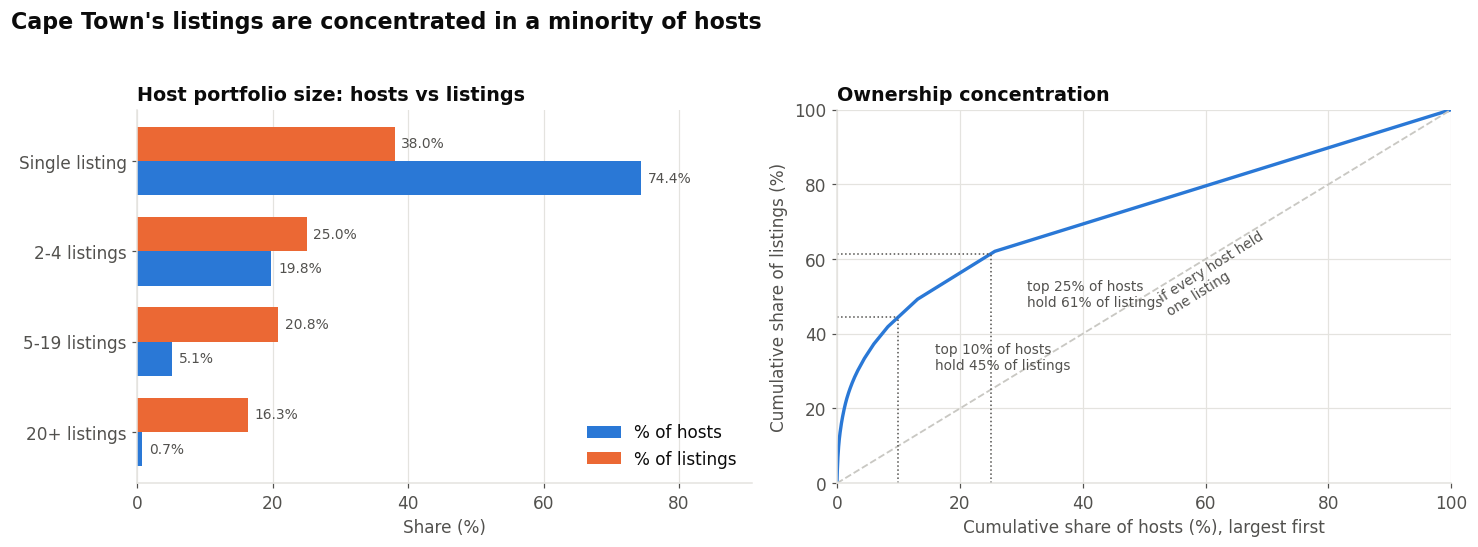

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))

# Left: hosts vs listings, the asymmetry is the whole point
ax = axes[0]
y = np.arange(len(ORDER))
h = 0.38
ax.barh(y + h/2, by_profile["% of hosts"], h, color=SERIES[0], label="% of hosts")
ax.barh(y - h/2, by_profile["% of listings"], h, color=SERIES[1], label="% of listings")
for yi, (a, b) in enumerate(zip(by_profile["% of hosts"], by_profile["% of listings"])):
    ax.text(a + 1, yi + h/2, f"{a:.1f}%", va="center", fontsize=9, color=INK_DIM)
    ax.text(b + 1, yi - h/2, f"{b:.1f}%", va="center", fontsize=9, color=INK_DIM)
ax.set_yticks(y, ORDER)
ax.invert_yaxis()
ax.set_xlabel("Share (%)")
ax.set_title("Host portfolio size: hosts vs listings", loc="left")
ax.legend(frameon=False, loc="lower right")
ax.grid(axis="y", visible=False)
ax.set_xlim(0, max(by_profile["% of hosts"].max(), by_profile["% of listings"].max()) * 1.22)

# Right: Lorenz-style concentration curve
ax = axes[1]
sizes = np.sort(host_size.values)[::-1]
cum_hosts = np.arange(1, len(sizes) + 1) / len(sizes) * 100
cum_listings = np.cumsum(sizes) / sizes.sum() * 100
ax.plot(cum_hosts, cum_listings, color=SERIES[0], linewidth=2.2)
ax.plot([0, 100], [0, 100], color=MUTED, linestyle="--", linewidth=1.2)
ax.text(52, 45, "if every host held\none listing", fontsize=9, color=INK_DIM, rotation=32)

for mark in (10, 25):
    yv = np.interp(mark, cum_hosts, cum_listings)
    ax.plot([mark, mark], [0, yv], color=INK_DIM, linewidth=1, linestyle=":")
    ax.plot([0, mark], [yv, yv], color=INK_DIM, linewidth=1, linestyle=":")
    ax.annotate(f"top {mark}% of hosts\nhold {yv:.0f}% of listings",
                xy=(mark, yv), xytext=(mark + 6, yv - 14), fontsize=9, color=INK_DIM)

ax.set_xlabel("Cumulative share of hosts (%), largest first")
ax.set_ylabel("Cumulative share of listings (%)")
ax.set_title("Ownership concentration", loc="left")
ax.set_xlim(0, 100); ax.set_ylim(0, 100)

fig.suptitle("Cape Town's listings are concentrated in a minority of hosts",
             fontsize=14.5, fontweight="bold", x=0.007, ha="left", y=1.03)
fig.tight_layout()
fig.savefig(OUTPUTS / "figure_2_ownership.png")
plt.show()

## 4. Geography and price

Inside Airbnb reports Cape Town location as **City of Cape Town ward numbers**, not suburb names —
the `neighbourhood` field is empty for every listing in this snapshot. Ward numbers mean nothing
to a reader on their own, which is exactly why this analysis ships with a map: on the dashboard
you can see which ward is the Atlantic Seaboard and which is the Cape Flats rather than being told.

Wards with fewer than 30 priced listings are excluded from the ranking — a median over a handful
of listings is noise.

In [9]:
MIN_LISTINGS = 30

ward = lis.groupby("neighbourhood_cleansed").agg(
    listings=("id", "size"),
    priced=("price_usable", "count"),
    median_price=("price_usable", "median"),
    pct_entire=("room_type", lambda s: (s == "Entire home/apt").mean() * 100),
    pct_commercial=("host_portfolio", lambda s: (s >= 2).mean() * 100),
    median_reviews=("number_of_reviews", "median"),
    lat=("latitude", "median"), lon=("longitude", "median"),
).sort_values("median_price", ascending=False)

ranked = ward[ward.priced >= MIN_LISTINGS].copy()
print(f"{len(ward)} wards with listings; {len(ranked)} have >= {MIN_LISTINGS} priced listings\n")
print("MOST EXPENSIVE WARDS")
print(ranked.head(10).round(1).to_string())
print("\nLEAST EXPENSIVE WARDS")
print(ranked.tail(10).round(1).to_string())

85 wards with listings; 45 have >= 30 priced listings

MOST EXPENSIVE WARDS
                        listings  priced  median_price  pct_entire  pct_commercial  median_reviews   lat   lon
neighbourhood_cleansed                                                                                        
Ward 62                      696     596        4265.0        90.7            57.9             5.0 -34.0  18.4
Ward 71                      306     260        2939.9        88.6            38.6             4.0 -34.1  18.4
Ward 69                      545     473        2935.2        87.7            50.3             7.0 -34.1  18.4
Ward 74                     1226    1073        2904.9        86.4            57.5             8.0 -34.0  18.4
Ward 61                     1075     985        2511.0        89.4            52.5            15.0 -34.2  18.4
Ward 54                     4333    3882        2510.2        89.3            75.0            10.0 -33.9  18.4
Ward 59                      646    

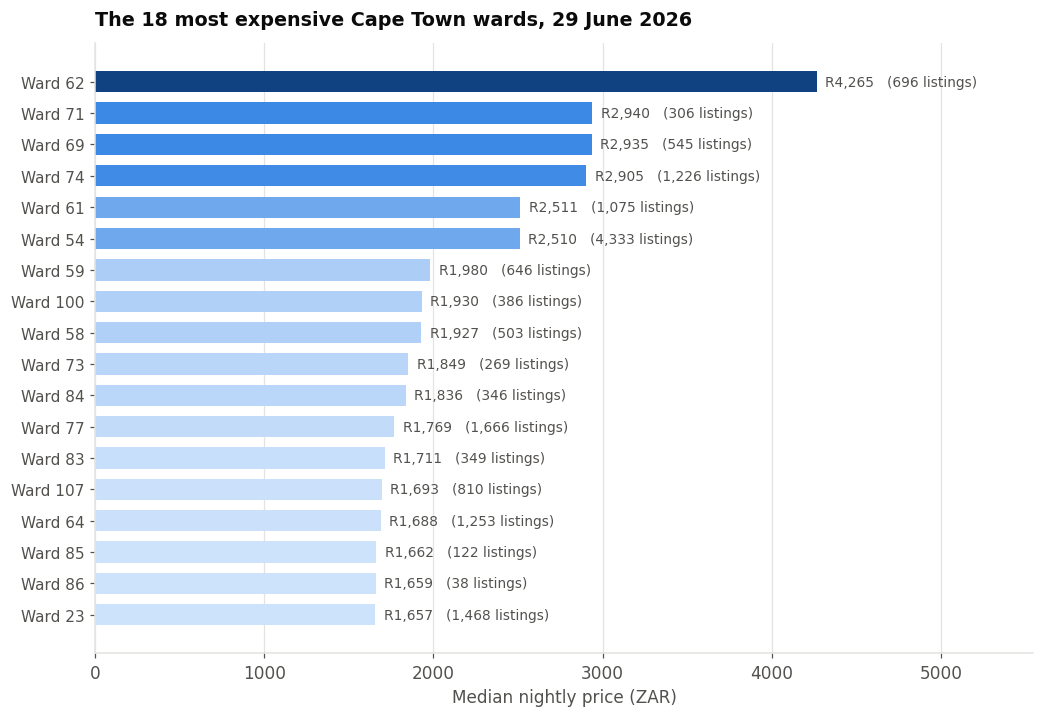

Price range across wards: R701 to R4,265 — a 6.1x spread.


In [10]:
fig, ax = plt.subplots(figsize=(11, 7.2))

top = ranked.head(18).iloc[::-1]
norm = mpl.colors.Normalize(vmin=top.median_price.min(), vmax=top.median_price.max())
cmap = mpl.colors.LinearSegmentedColormap.from_list("blues", SEQ)

y = np.arange(len(top))
ax.barh(y, top.median_price, color=[cmap(norm(v)) for v in top.median_price], height=0.68)
for yi, (v, n) in enumerate(zip(top.median_price, top.listings)):
    ax.text(v + top.median_price.max() * 0.012, yi, f"R{v:,.0f}   ({n:,} listings)",
            va="center", fontsize=9, color=INK_DIM)

ax.set_yticks(y, top.index, fontsize=10)
ax.set_xlabel("Median nightly price (ZAR)")
ax.set_title(f"The 18 most expensive Cape Town wards, {SNAPSHOT}", loc="left", pad=12)
ax.grid(axis="y", visible=False)
ax.set_xlim(0, top.median_price.max() * 1.30)

fig.savefig(OUTPUTS / "figure_3_ward_prices.png")
plt.show()

print(f"Price range across wards: R{ranked.median_price.min():,.0f} to "
      f"R{ranked.median_price.max():,.0f} — a {ranked.median_price.max()/ranked.median_price.min():.1f}x spread.")

### What actually drives the nightly rate

Median price by capacity and room type. Capacity is the dominant lever, which is worth stating
plainly: a lot of "Cape Town is expensive" is really "Cape Town lists large houses".

In [11]:
pivot = (lis[lis.price_usable.notna() & lis.accommodates.between(1, 10)]
         .pivot_table(index="accommodates", columns="room_type",
                      values="price_usable", aggfunc="median"))
pivot = pivot[[c for c in ["Entire home/apt", "Private room"] if c in pivot.columns]]
print(pivot.round(0).to_string())

corr = (lis[["price_usable", "accommodates", "bedrooms", "number_of_reviews",
             "availability_365", "review_scores_rating"]]
        .corr(method="spearman")["price_usable"].drop("price_usable").sort_values(ascending=False))
print("\nSpearman correlation with nightly price:")
print(corr.round(3).to_string())

room_type     Entire home/apt  Private room
accommodates                               
1                       791.0         601.0
2                      1285.0        1050.0
3                      1413.0        1228.0
4                      2159.0        1599.0
5                      2940.0        1988.0
6                      4388.0        3193.0
7                      5186.0        3344.0
8                      7660.0        3972.0
9                      7099.0        7162.0
10                    10112.0        3354.0



Spearman correlation with nightly price:
accommodates            0.706
bedrooms                0.699
review_scores_rating    0.193
availability_365       -0.119
number_of_reviews      -0.134


## 5. Licensing

South African cities have moved toward requiring short-term rentals to register. Inside Airbnb
captures whatever licence number a host displays.

In [12]:
licensed = int(lis.license.notna().sum())
print(f"Listings displaying a licence number: {licensed:,} of {len(lis):,} ({licensed/len(lis):.1%})")
print()
print("Read this carefully. The field records what a host has *published on the listing*, not")
print("whether a licence exists. A near-zero rate is consistent with either widespread")
print("non-compliance or with hosts simply not publishing a number they hold.")
print("The data cannot separate the two, and this notebook does not claim to.")

Listings displaying a licence number: 162 of 27,381 (0.6%)

Read this carefully. The field records what a host has *published on the listing*, not
whether a licence exists. A near-zero rate is consistent with either widespread
non-compliance or with hosts simply not publishing a number they hold.
The data cannot separate the two, and this notebook does not claim to.


## 6. Forward availability

10 million rows of nightly availability, one row per listing per date for the year ahead.

This is **not** clean seasonality, and it would be misleading to present it as such. Two
confounds sit in the series:

- **Unavailable conflates booked with host-blocked.** A host who closes their calendar for
  winter looks identical to one who is fully booked.
- **A booking curve.** Nights close to the scrape date are more likely to be taken simply
  because they are nearer; distant months look emptier because nobody has booked them yet.

The first and last months are also partial and are dropped.

In [13]:
cal = pd.read_csv(DATA / "calendar.csv.gz", parse_dates=["date"],
                  usecols=["listing_id", "date", "available"],
                  dtype={"listing_id": "int64", "available": "category"}, low_memory=False)
cal["month"] = cal.date.dt.to_period("M")

monthly = cal.groupby("month").agg(nights=("available", "size"),
                                   unavailable=("available", lambda s: (s == "f").sum()))
# Drop partial months at either end — they are a fraction of a full month's nights
full = monthly[monthly.nights > monthly.nights.max() * 0.85].copy()
full["unavailable_pct"] = (full.unavailable / full.nights * 100).round(1)

print(f"{len(cal):,} listing-nights over {cal.date.min():%b %Y} to {cal.date.max():%b %Y}")
print(f"Dropped {len(monthly) - len(full)} partial months at the edges\n")
print(full[["nights", "unavailable_pct"]].to_string())

9,994,036 listing-nights over Jun 2026 to Jul 2027
Dropped 2 partial months at the edges

         nights  unavailable_pct
month                           
2026-07  826744             43.8
2026-08  848811             35.3
2026-09  821430             31.5
2026-10  848811             35.0
2026-11  821430             35.9
2026-12  848811             40.3
2027-01  848811             43.1
2027-02  766668             40.2
2027-03  848811             37.0
2027-04  821430             41.0
2027-05  848811             41.7
2027-06  817576             43.4


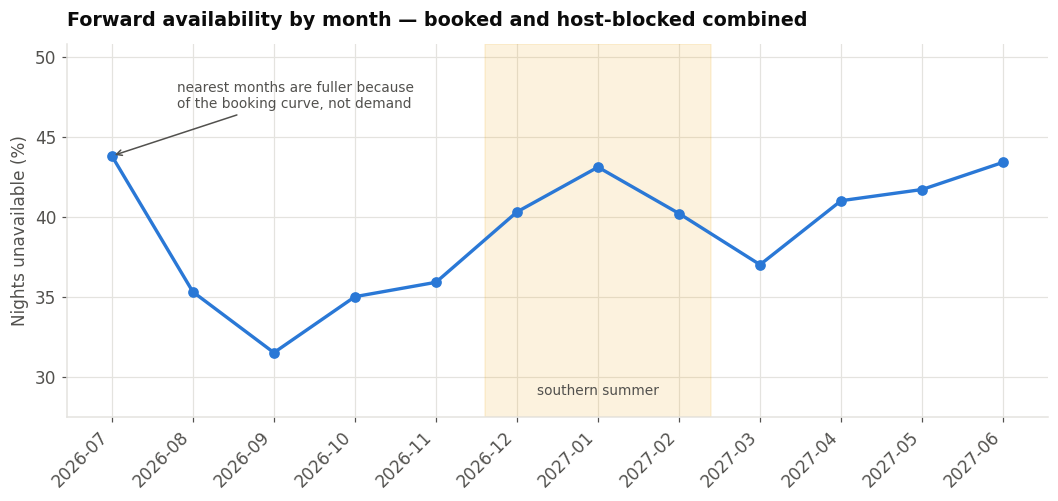

In [14]:
fig, ax = plt.subplots(figsize=(11.5, 4.4))

x = np.arange(len(full))
ax.plot(x, full.unavailable_pct, color=SERIES[0], linewidth=2.2, marker="o", markersize=6)
ax.set_xticks(x, [str(m) for m in full.index], rotation=45, ha="right")
ax.set_ylabel("Nights unavailable (%)")
ax.set_title("Forward availability by month — booked and host-blocked combined",
             loc="left", pad=12)

peak = full.unavailable_pct.idxmax()
ax.annotate("nearest months are fuller because\nof the booking curve, not demand",
            xy=(0, full.unavailable_pct.iloc[0]), xytext=(0.8, full.unavailable_pct.max() + 3),
            fontsize=9, color=INK_DIM,
            arrowprops=dict(arrowstyle="->", color=INK_DIM, lw=1))

summer = [i for i, m in enumerate(full.index) if m.month in (12, 1, 2)]
if summer:
    ax.axvspan(min(summer) - 0.4, max(summer) + 0.4, color=SERIES[3], alpha=0.13)
    ax.text(np.mean(summer), full.unavailable_pct.min() - 2.6, "southern summer",
            ha="center", fontsize=9, color=INK_DIM)

ax.set_ylim(full.unavailable_pct.min() - 4, full.unavailable_pct.max() + 7)
fig.savefig(OUTPUTS / "figure_4_availability.png")
plt.show()

## 7. Export for the dashboard and the Power BI model

One cleaned pipeline, three consumers: this notebook, an interactive web dashboard, and a Power BI
star schema. Exporting from a single point means the three cannot drift apart.

In [15]:
# --- Ward aggregates for the choropleth ---
ward_out = ward.reset_index().rename(columns={"neighbourhood_cleansed": "ward"})
ward_out = ward_out.round({"median_price": 0, "pct_entire": 1,
                           "pct_commercial": 1, "lat": 5, "lon": 5})
ward_out.to_csv(OUTPUTS / "ward_summary.csv", index=False)

# --- Listing-level columnar payload for the dashboard ---
# Pre-aggregating into cells and taking a weighted median of cell medians is only an
# approximation: it lands ~15% below the true median on this distribution. Shipping the
# underlying values instead means every figure the dashboard shows under any filter
# combination is exact, at a cost of a few hundred KB.
sub = lis.dropna(subset=["price_usable"]).copy()

ward_names = sorted(sub.neighbourhood_cleansed.unique())
room_names = sorted(sub.room_type.unique())
host_names = [h for h in ORDER if h in set(sub.host_profile)]

w_ix = {v: i for i, v in enumerate(ward_names)}
r_ix = {v: i for i, v in enumerate(room_names)}
h_ix = {v: i for i, v in enumerate(host_names)}

payload = {
    "snapshot": SNAPSHOT,
    "totals": {
        "listings": int(len(lis)),
        "priced": int(len(sub)),
        "hosts": int(lis.host_id.nunique()),
        "median_price": float(round(p.median())),
        "pct_entire": float(round((lis.room_type == "Entire home/apt").mean() * 100, 1)),
        "pct_commercial": float(round((lis.host_portfolio >= 2).mean() * 100, 1)),
        "pct_licensed": float(round(lis.license.notna().mean() * 100, 2)),
    },
    "dims": {"wards": ward_names, "rooms": room_names, "hosts": host_names},
    "l": {
        "w": [int(w_ix[v]) for v in sub.neighbourhood_cleansed],
        "r": [int(r_ix[v]) for v in sub.room_type],
        "h": [int(h_ix[v]) for v in sub.host_profile],
        "p": [int(round(v)) for v in sub.price_usable],
    },
    "host_profile": by_profile.reset_index().replace({np.nan: None}).round(1).to_dict(orient="records"),
    "availability": [{"month": str(m), "unavailable_pct": float(v)}
                     for m, v in full.unavailable_pct.items()],
    "concentration": {"cum_hosts": [round(float(v), 2) for v in cum_hosts[::40]],
                      "cum_listings": [round(float(v), 2) for v in cum_listings[::40]]},
}
(DASH / "data.json").write_text(json.dumps(payload, separators=(",", ":")), encoding="utf-8")
print(f"dashboard/data.json  {(DASH / 'data.json').stat().st_size/1024:.0f} KB "
      f"({len(sub):,} priced listings, exact medians under any filter)")

# Sanity check: the dashboard must reproduce the notebook's headline median exactly
assert int(round(np.median(payload['l']['p']))) == int(round(p.median())), "median mismatch"
print(f"check: unfiltered median R{np.median(payload['l']['p']):,.0f} matches the notebook")

dashboard/data.json  288 KB (24,433 priced listings, exact medians under any filter)
check: unfiltered median R1,726 matches the notebook


In [16]:
# --- Power BI star schema ---
fact = lis[["id", "host_id", "neighbourhood_cleansed", "room_type", "property_type",
            "accommodates", "bedrooms", "price_usable", "minimum_nights",
            "availability_365", "number_of_reviews", "number_of_reviews_ltm",
            "review_scores_rating", "host_is_superhost", "license",
            "latitude", "longitude"]].copy()
fact.columns = ["listing_id", "host_id", "ward", "room_type", "property_type",
                "accommodates", "bedrooms", "price_zar", "minimum_nights",
                "availability_365", "reviews_total", "reviews_ltm",
                "review_score", "is_superhost", "licence", "latitude", "longitude"]
fact["is_licensed"] = fact.licence.notna()
fact = fact.drop(columns=["licence"])
fact.to_csv(PBI / "fact_listings.csv", index=False)

dim_ward = ward_out[["ward", "listings", "median_price", "pct_entire", "pct_commercial",
                     "lat", "lon"]]
dim_ward.to_csv(PBI / "dim_ward.csv", index=False)

dim_host = (lis.groupby("host_id")
              .agg(listings_held=("id", "size"),
                   is_superhost=("host_is_superhost", "first"),
                   host_since=("host_since", "first"))
              .reset_index())
dim_host["host_profile"] = dim_host.listings_held.map(profile)
dim_host.to_csv(PBI / "dim_host.csv", index=False)

for f in sorted(PBI.glob("*.csv")):
    print(f"powerbi/{f.name:<22} {f.stat().st_size/1024:>7,.0f} KB")

powerbi/dim_host.csv               412 KB
powerbi/dim_ward.csv                 4 KB
powerbi/fact_listings.csv        3,461 KB


## 8. Findings

**Cape Town's short-term rental market is not, in the main, home sharing.**

**84.5% of listings are entire homes or apartments** — whole properties, not spare rooms. These are
dwellings withdrawn from the residential rental pool, in a city with an acknowledged housing
shortage.

**A quarter of hosts control almost two-thirds of the listings.** Hosts with two or more properties
are 25.6% of hosts but hold 62.0% of listings. Hosts with twenty or more — 0.7% of hosts — hold
16.3%. The distribution is that of an industry with professional operators, not a neighbourhood of
residents letting a room.

**Location premiums are extreme.** Median nightly rates vary several-fold across wards, and because
Inside Airbnb reports Cape Town by ward number rather than suburb, that pattern is only legible on
a map — which is why this project ships one.

**Almost no listing displays a licence.** 0.6% show a licence number. That figure is worth stating
carefully: the field records what a host *published*, not what they hold, and the data cannot
distinguish non-compliance from non-disclosure.

### Limitations

A snapshot, not a history. One scrape on 29 June 2026 — it cannot show whether concentration is
rising or falling, which is the question a policymaker would actually ask.

**Listed price is not achieved price.** Inside Airbnb captures the advertised nightly rate, before
discounts, cleaning fees and platform commission, and with no evidence anyone paid it.

**Availability is not occupancy.** An unavailable night is either booked or blocked by the host, and
the two are indistinguishable here. Combined with the booking curve, the monthly series should be
read as a shape, not a measurement.

Host identity is per account. One operator running several accounts would appear as several small
hosts, so the concentration measured here is a **floor**, not a ceiling.

### Reproducing

```bash
pip install -r requirements.txt
python src/download_data.py
jupyter notebook notebooks/cape_town_rental_market.ipynb
```

**Data:** [Inside Airbnb](https://insideairbnb.com/get-the-data/) — Cape Town snapshot,
29 June 2026, published under CC BY 4.0.